In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import statsmodels.api as sm
from statsmodels import robust

# 1. Load your uploaded metro_data.csv
df = pd.read_csv('/content/drive/MyDrive/metro_data.csv')
df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y')
df['Total_Commuters'] = pd.to_numeric(df['Total_Commuters'], errors='coerce')

print("✅ Data loaded:", df.shape)
print(df.head())
print(df.info())


✅ Data loaded: (78, 3)
        Date        Day  Total_Commuters
0 2025-06-03    Tuesday           920000
1 2025-06-04  Wednesday           940000
2 2025-06-05   Thursday          1070000
3 2025-06-06     Friday          1055000
4 2025-06-07   Saturday           890000
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 78 entries, 0 to 77
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Date             78 non-null     datetime64[ns]
 1   Day              78 non-null     object        
 2   Total_Commuters  78 non-null     int64         
dtypes: datetime64[ns](1), int64(1), object(1)
memory usage: 2.0+ KB
None


In [ ]:
# Check inconsistencies
print("Missing values:\n", df.isnull().sum())
print("\nData types:\n", df.dtypes)
print("\nDate range:", df['Date'].min(), "to", df['Date'].max())

# Summary statistics
print("\n📈 Summary Statistics:")
print(df['Total_Commuters'].describe())


Missing values:
 Date               0
Day                0
Total_Commuters    0
dtype: int64

Data types:
 Date               datetime64[ns]
Day                        object
Total_Commuters             int64
dtype: object

Date range: 2025-06-03 00:00:00 to 2025-12-02 00:00:00

📈 Summary Statistics:
count    7.800000e+01
mean     1.023577e+06
std      6.964230e+04
min      8.400000e+05
25%      9.862500e+05
50%      1.041000e+06
75%      1.072750e+06
max      1.125000e+06
Name: Total_Commuters, dtype: float64


In [ ]:
# Std Dev, MAD, IQR
std_dev = df['Total_Commuters'].std()
mad = robust.mad(df['Total_Commuters'])
q1, q3 = df['Total_Commuters'].quantile([0.25, 0.75])
iqr = q3 - q1

print(f"Std Dev: {std_dev:,.0f}")
print(f"MAD: {mad:,.0f}")
print(f"IQR: {iqr:,.0f}")


Std Dev: 69,642
MAD: 58,563
IQR: 86,500


In [ ]:
from scipy import stats

# Shapiro-Wilk Test for normality
shapiro_test = stats.shapiro(df['Total_Commuters'])
print(f"Shapiro-Wilk Test Statistic: {shapiro_test.statistic:.3f}, p-value: {shapiro_test.pvalue:.3f}")

if shapiro_test.pvalue > 0.05:
    print("\nBased on the Shapiro-Wilk test, the data appears to be normally distributed (p > 0.05).")
else:
    print("\nBased on the Shapiro-Wilk test, the data does not appear to be normally distributed (p <= 0.05).")

Shapiro-Wilk Test Statistic: 0.935, p-value: 0.001

Based on the Shapiro-Wilk test, the data does not appear to be normally distributed (p <= 0.05).


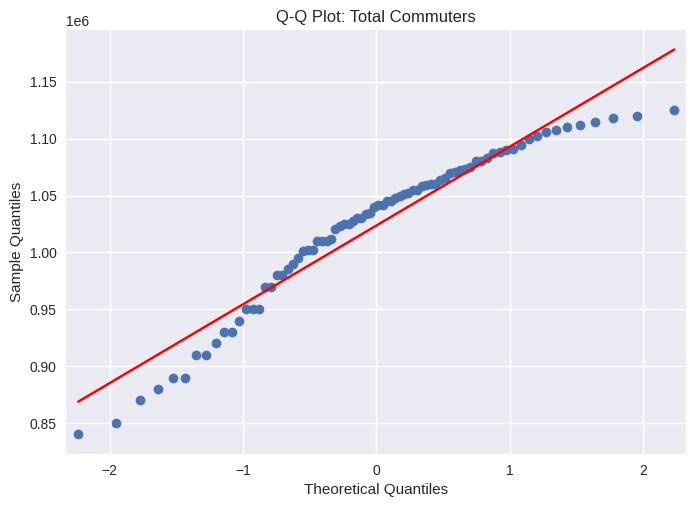

In [ ]:
import statsmodels.api as sm
import matplotlib.pyplot as plt

# Q-Q plot for visual inspection of normality
sm.qqplot(df['Total_Commuters'], line='s')
plt.title('Q-Q Plot: Total Commuters')
plt.show()

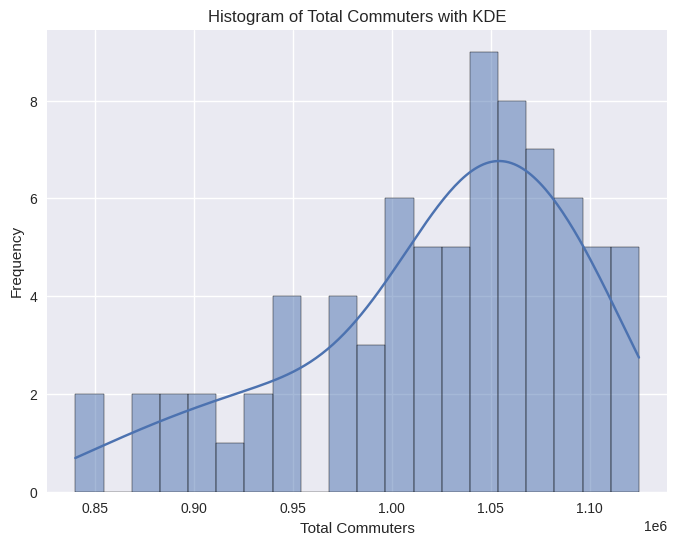

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Histogram with KDE to visually inspect the distribution
plt.figure(figsize=(8, 6))
sns.histplot(df['Total_Commuters'], kde=True, bins=20)
plt.title('Histogram of Total Commuters with KDE')
plt.xlabel('Total Commuters')
plt.ylabel('Frequency')
plt.show()

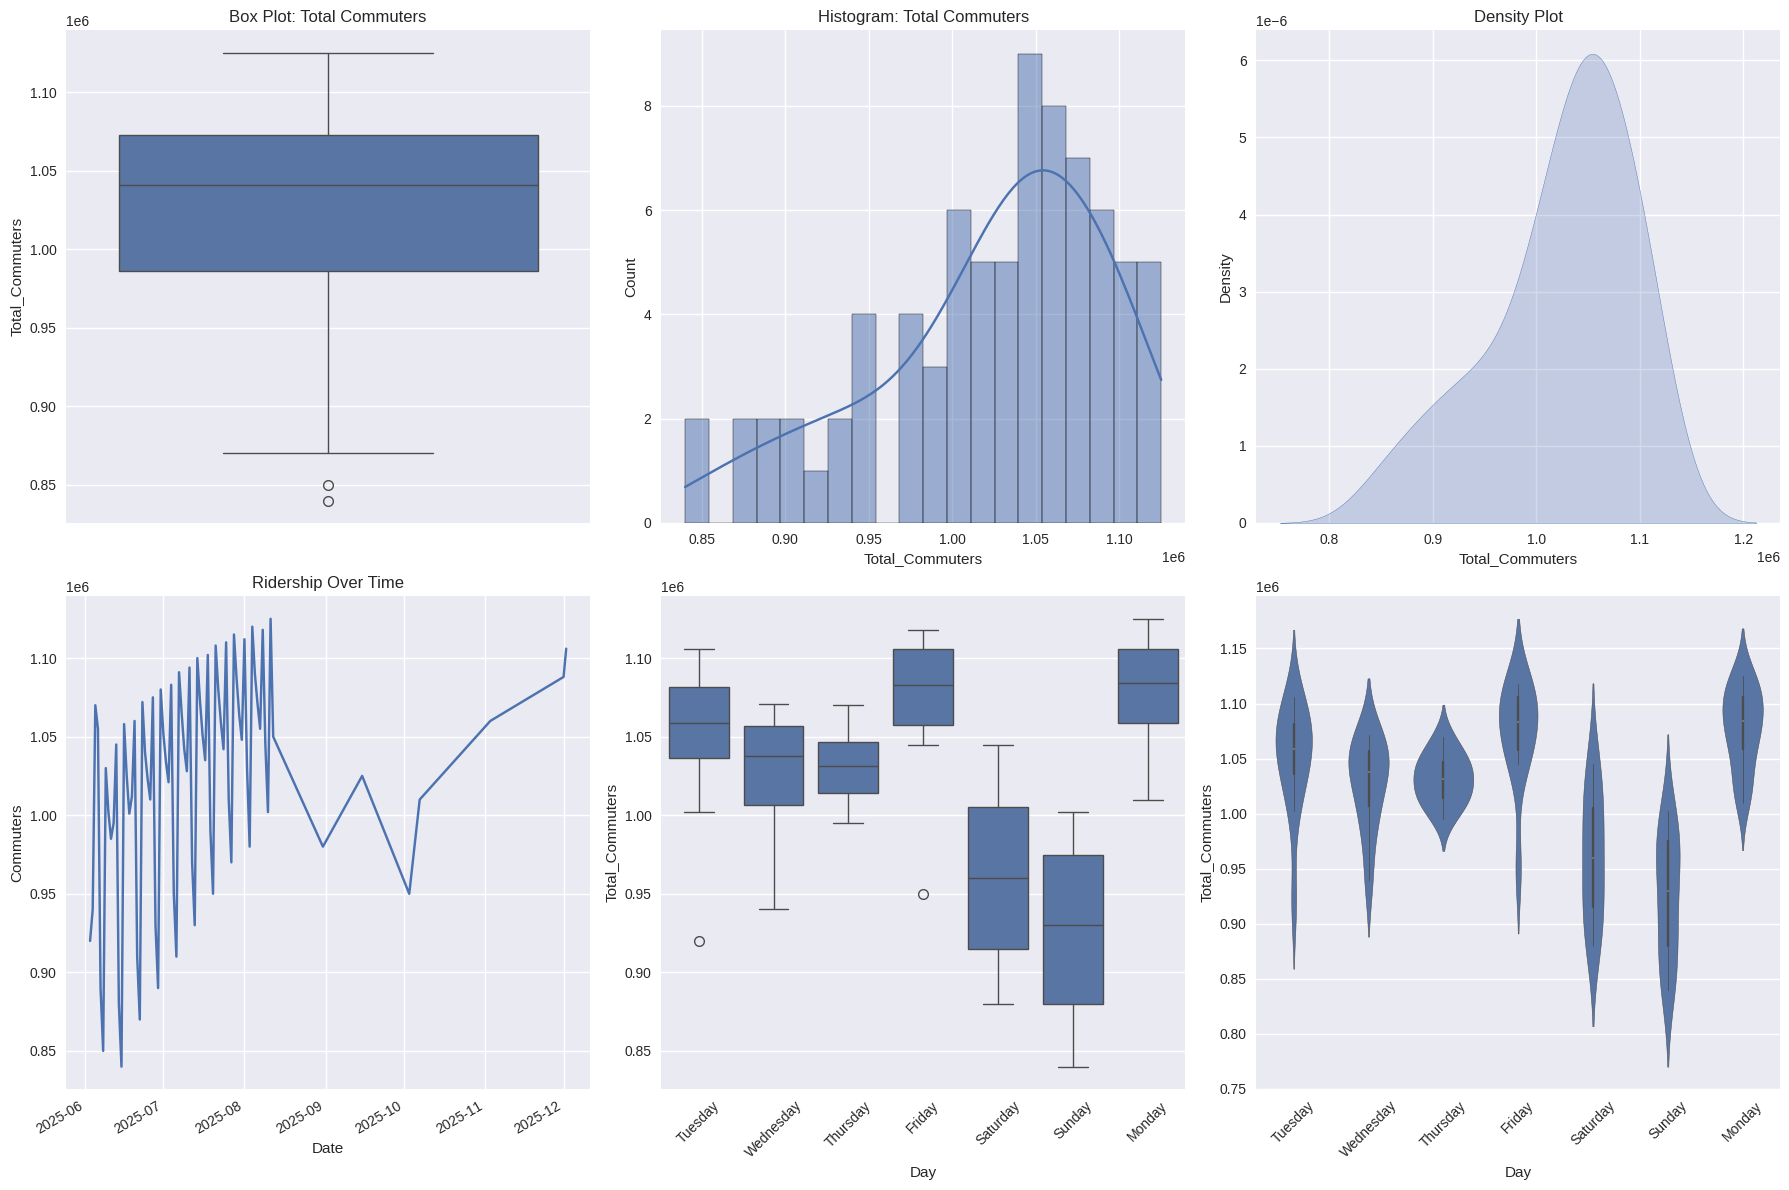

In [ ]:
plt.style.use('seaborn-v0_8')
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# Box plot
sns.boxplot(y=df['Total_Commuters'], ax=axes[0,0])
axes[0,0].set_title('Box Plot: Total Commuters')

# Histogram
sns.histplot(df['Total_Commuters'], kde=True, bins=20, ax=axes[0,1])
axes[0,1].set_title('Histogram: Total Commuters')

# Density plot
sns.kdeplot(df['Total_Commuters'], fill=True, ax=axes[0,2])
axes[0,2].set_title('Density Plot')

# Time series
df.set_index('Date')['Total_Commuters'].plot(ax=axes[1,0], title='Ridership Over Time')
axes[1,0].set_ylabel('Commuters')

# Day of week boxplot
sns.boxplot(x='Day', y='Total_Commuters', data=df, ax=axes[1,1])
axes[1,1].tick_params(axis='x', rotation=45)

# Violin plot by day
sns.violinplot(x='Day', y='Total_Commuters', data=df, ax=axes[1,2])
axes[1,2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


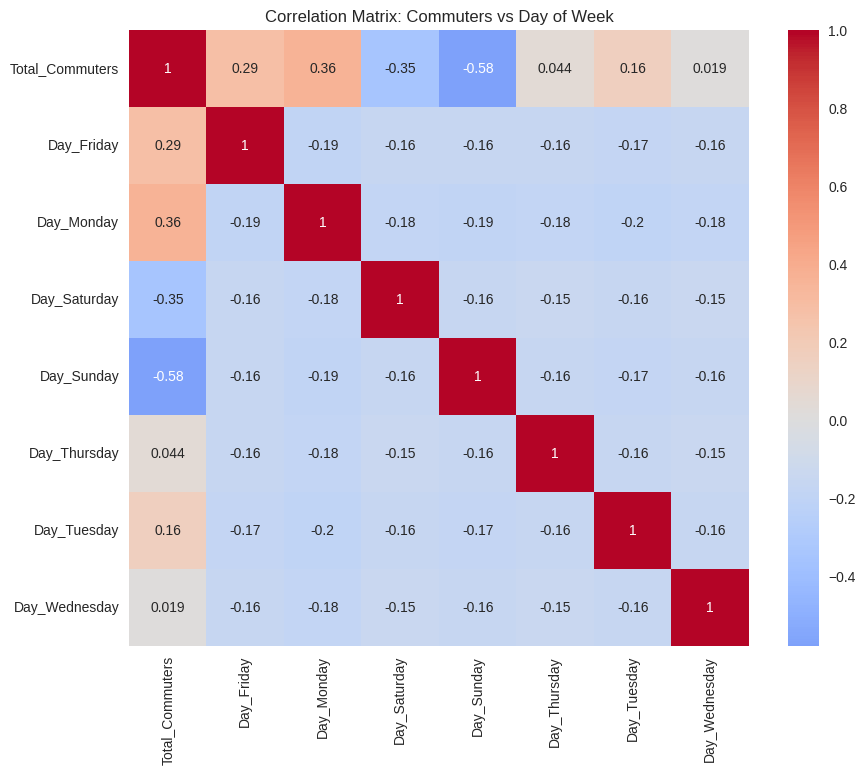

In [ ]:
# Encode day for correlation
day_encoded = pd.get_dummies(df['Day'], prefix='Day')
df_numeric = pd.concat([df[['Total_Commuters']], day_encoded], axis=1)

corr_matrix = df_numeric.corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Matrix: Commuters vs Day of Week')
plt.show()


In [ ]:
import scipy.stats as stats

# Calculate Spearman's rank correlation between Total_Commuters and Day_Order
spearman_corr, p_value = stats.spearmanr(df['Total_Commuters'], df['Day_Order'])

print(f"Spearman's Rank Correlation Coefficient: {spearman_corr:.3f}")
print(f"P-value: {p_value:.3f}")

if p_value < 0.05:
    print("There is a statistically significant monotonic relationship between Total Commuters and Day of the Week.")
else:ude
    print("There is no statistically significant monotonic relationship between Total Commuters and Day of the Week.")

Spearman's Rank Correlation Coefficient: -0.588
P-value: 0.000
There is a statistically significant monotonic relationship between Total Commuters and Day of the Week.


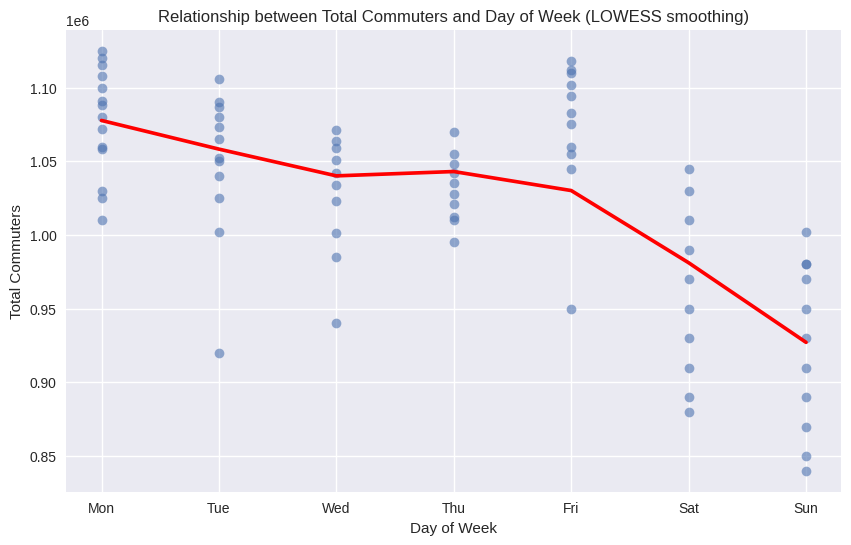

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.regplot(x='Day_Order', y='Total_Commuters', data=df, lowess=True, scatter_kws={'alpha':0.6}, line_kws={'color':'red'})
plt.xticks(range(7), ['Mon','Tue','Wed','Thu','Fri','Sat','Sun'])
plt.title('Relationship between Total Commuters and Day of Week (LOWESS smoothing)')
plt.xlabel('Day of Week')
plt.ylabel('Total Commuters')
plt.grid(True)
plt.show()